In [1]:
import pandas as pd

path = '../data/processed/ai4i2020_new.csv'
df = pd.read_csv(path, index_col='UDI')
print('Dataset loaded')
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

df.sample(10)

Dataset loaded
Rows: 9973
Columns: 13


,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rad/s],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,,,,,,,,,,,,,
2725,M17584,1,299.8,309.3,153.938040,42.7,119,0,0,0,0,0,0
4862,L52041,0,303.5,312.3,203.784643,21.1,112,0,0,0,0,0,0
3459,L50638,0,301.5,310.4,139.172555,46.6,24,0,0,0,0,0,0
8551,L55730,0,298.3,309.2,152.471963,45.5,75,0,0,0,0,0,0
8228,M23087,1,299.1,310.4,159.592907,51.4,66,0,0,0,0,0,0
4835,M19694,1,303.4,311.9,158.126830,42.2,36,0,0,0,0,0,0
6333,M21192,1,300.5,309.9,208.811192,19.8,189,0,0,0,0,0,0
8693,L55872,0,297.1,308.4,165.771372,31.9,2,0,0,0,0,0,0
4150,L51329,0,301.9,310.4,167.865767,37.6,69,0,0,0,0,0,0


In [2]:
print('Separating all column by type:\n')
identifier = [
    'UDI', 'Product ID'
]
failure = [
    'TWF', 'HDF', 'PWF', 'OSF', 'RNF'
]
target = [
    'Machine failure'
]
feature = [
    'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rad/s]',	'Torque [Nm]', 'Tool wear [min]'
]

print(f'Identifier: {identifier}')
print(f'Failure: {failure}')
print(f'Features: {feature}')
print(f'Target: {target}')



Separating all column by type:

Identifier: ['UDI', 'Product ID']
Failure: ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rad/s]', 'Torque [Nm]', 'Tool wear [min]']
Target: ['Machine failure']


In [3]:
from sklearn.model_selection import train_test_split

X, y = df[feature], df[target[0]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size= 0.2, #80% train - 20% test
    random_state= 42,
    stratify= y
    )
eighty = df.shape[0] * 0.8
twenty = df.shape[0] * 0.2

print(f'X_train and y_train must be {eighty:.0f} size: \n-> X_train {X_train.shape[0]} and y_train {y_train.shape[0]} size\n')
print(f'X_test and y_test must be {twenty:.0f} size: \n-> X_test {X_test.shape[0]} and y_test {y_test.shape[0]}')


X_train and y_train must be 7978 size: 
-> X_train 7978 and y_train 7978 size

X_test and y_test must be 1995 size: 
-> X_test 1995 and y_test 1995


In [4]:
print('Finding the best hyperparameters for this dataset\n')
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state= 42,
    n_jobs = -1
)

parameters = {
    'n_estimators': randint(100,500),
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions= parameters,
    n_iter= 10,
    cv= 5,
    scoring= 'f1',
    n_jobs= -1,
    random_state= 42
)
random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_
print(f'Best parameters: {best_rf}')

Finding the best hyperparameters for this dataset

Best parameters: RandomForestClassifier(max_depth=14, min_samples_leaf=2, min_samples_split=7,
                       n_estimators=485, n_jobs=-1, random_state=42)


In [5]:
print('Training the model with the best hyperparameters')
rf = best_rf
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)


Training the model with the best hyperparameters


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


print('Precision: How frequent the model get it right? Low = lots of false alarms')
print('Recall: Of all failures, how much the model got? Low = machine broke without alarm')
print('F1-score: Harmonic mean')
print('Acurracy: Right hit / all hits\n')
print(classification_report(y_test, y_pred))

Precision: How frequent the model get it right? Low = lots of false alarms
Recall: Of all failures, how much the model got? Low = machine broke without alarm
F1-score: Harmonic mean
Acurracy: Right hit / all hits

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1929
           1       0.89      0.62      0.73        66

    accuracy                           0.98      1995
   macro avg       0.94      0.81      0.86      1995
weighted avg       0.98      0.98      0.98      1995



Confusion Matrix
True Negative  | False Positive
False Negative | True Positive


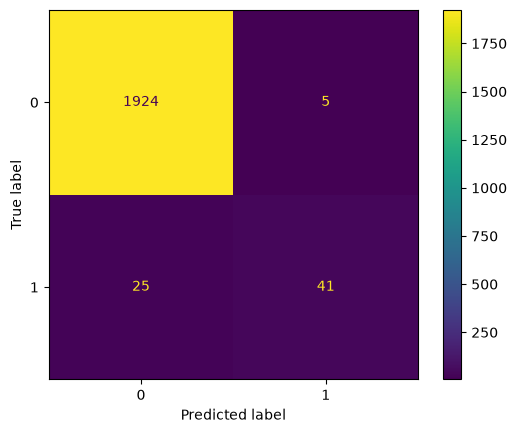

In [7]:
print('Confusion Matrix')
print('True Negative  | False Positive')
print('False Negative | True Positive')

cfm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cfm).plot()

In [8]:
rf_importance = pd.DataFrame({
    'feature' : feature,
    'importance' : rf.feature_importances_
}).sort_values(by = 'importance', ascending=True)

In [9]:
import plotly.express as px

fig = px.bar(
    x = rf_importance['importance'],
    y = rf_importance['feature']
)

fig.update_layout(
    title = dict(
        text = 'Feature importance',
        x = 0.5
    )
)

print('Visual way to see the feature importance, in order')
fig.show()

Visual way to see the feature importance, in order


Visualizing exemples of trees the model made:



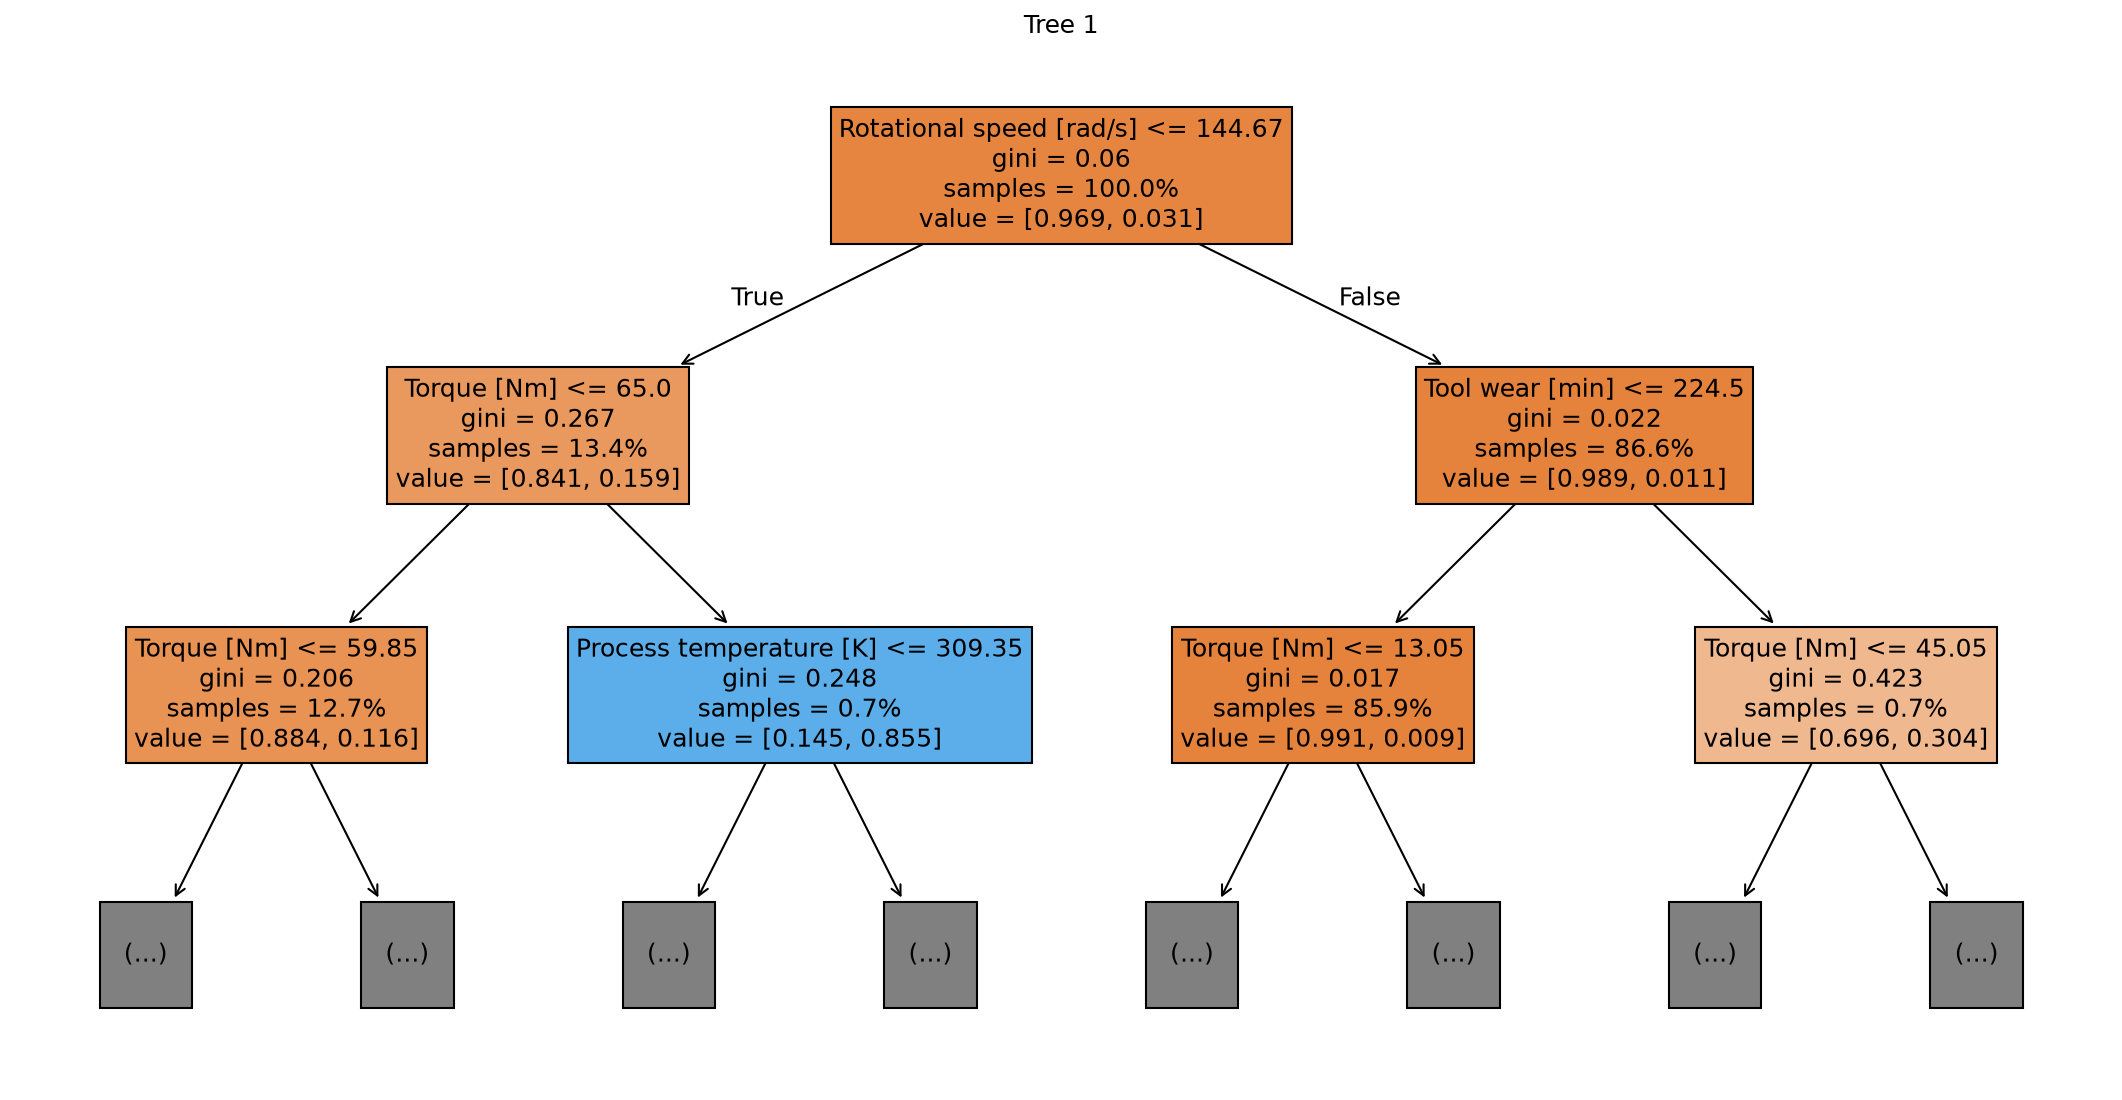

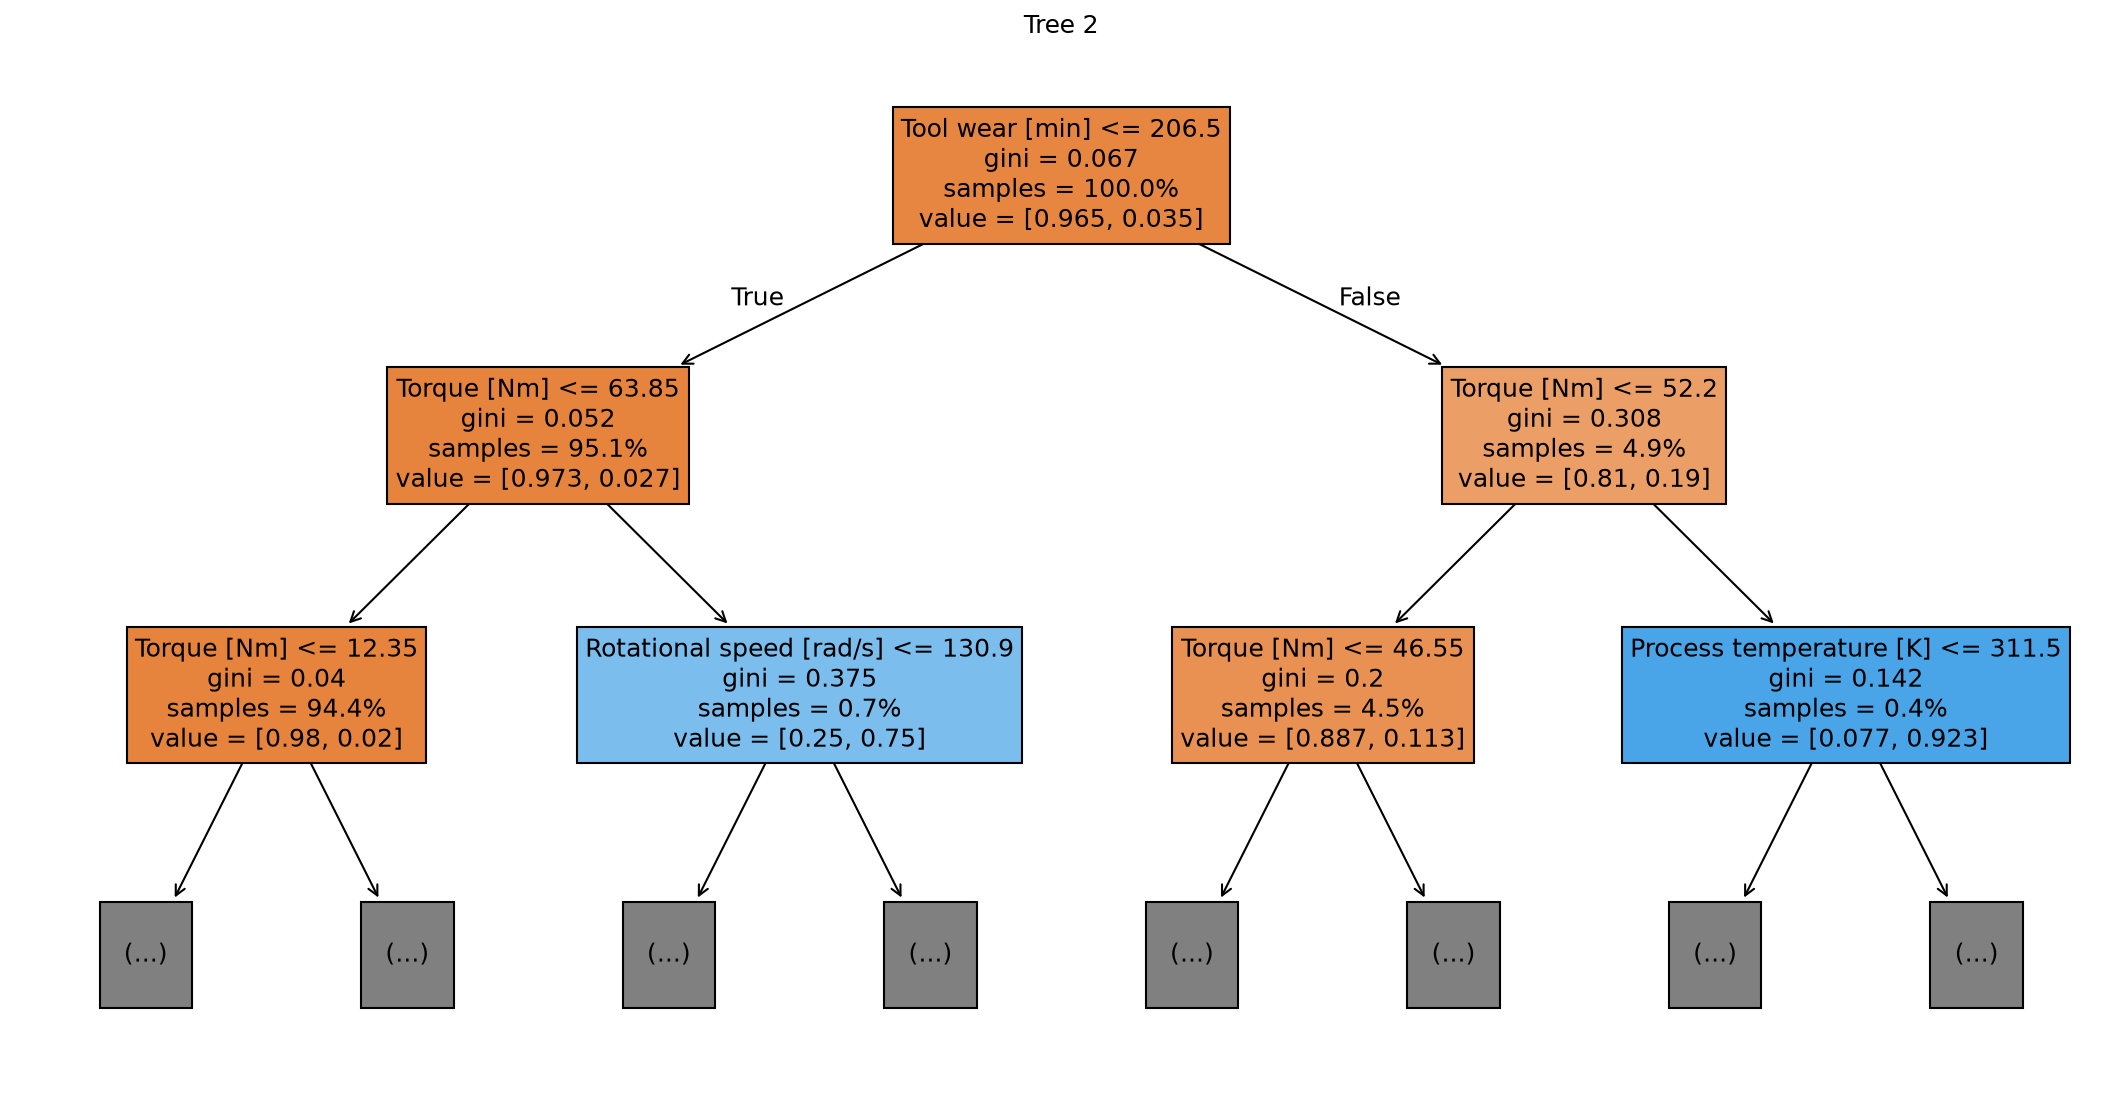

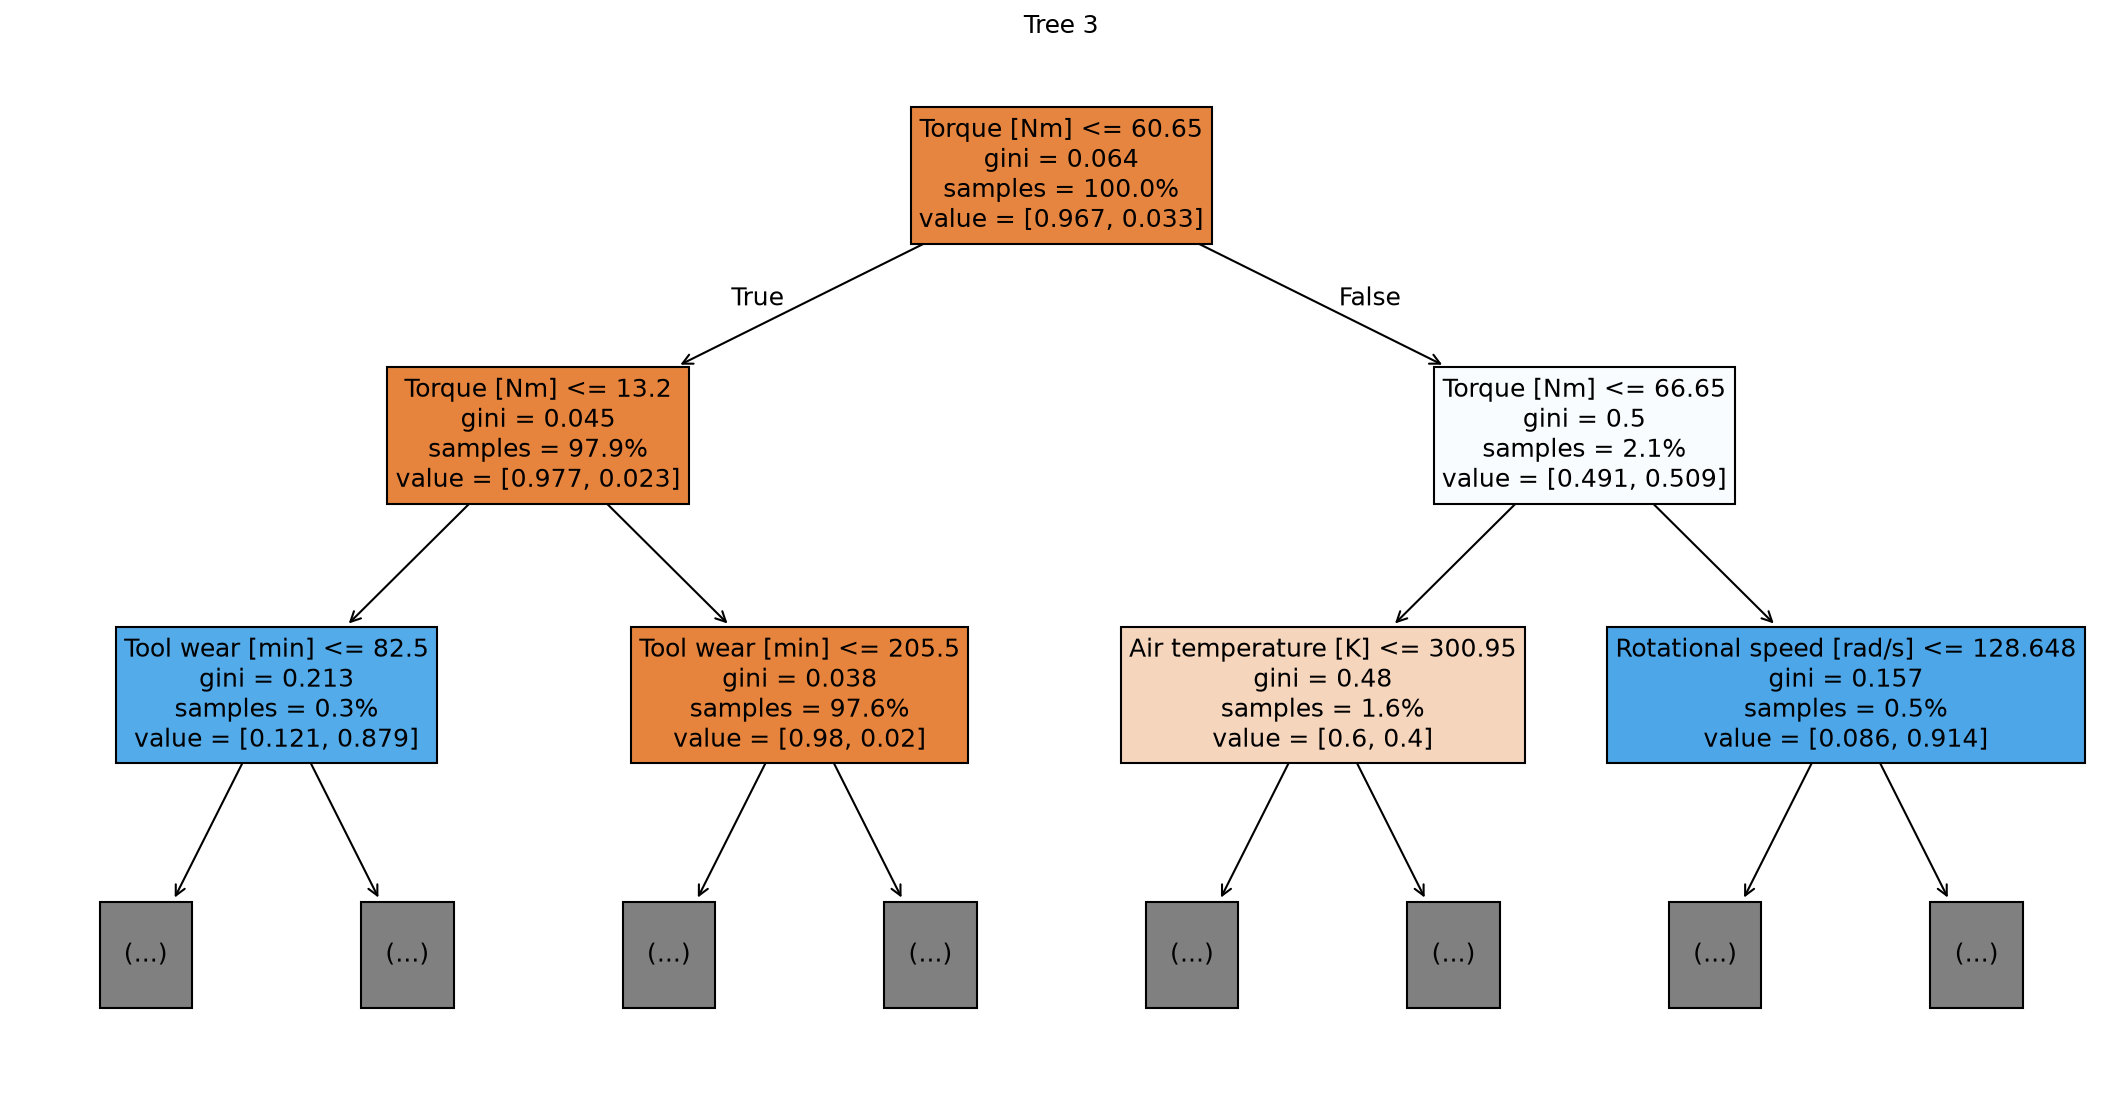

In [10]:
import matplotlib.pyplot as plt # plot_tree was built for matplotlib
from sklearn.tree import plot_tree

print('Visualizing exemples of trees the model made:\n')
for i in range(3):
    tree = rf.estimators_[i]
    fig, ax = plt.subplots(figsize = (18,9), dpi = 150)

    plot_tree(
        tree,
        feature_names= feature,
        filled= True, #the purer the color, more vibrant it is
        max_depth= 2, #limit the view to show only 3 levels of the tree
        proportion= True, #show the proportion of sample at each node
        impurity= True, #show the entropy (disorder) of each node. "GINI"
        fontsize= 12, #increase the letter
        ax= ax
    )

    ax.set_title(f'Tree {i+1}')
    plt.show()